In [1]:
import numpy as np
import sys
import matplotlib.pyplot as plt
from matplotlib import colormaps

sys.path.append("C:/Users/haoyu/Documents/GitHub/XRaySimulation")

from XRaySimulation import Pulse, DeviceSimu, util, Crystal

In [2]:
gVec = np.zeros((4, 360, 3))
sto220 = 1e4 * np.array([1, 1, 0]) / np.sqrt(2) * np.pi * 2 / 2.0003
sto313 = 1e4 * np.array([3, 1, 3]) / np.sqrt(19) * np.pi * 2 / 1.2980
sto111 = 1e4 * np.array([1, 1, 1]) / np.sqrt(3) * np.pi * 2 / 3.2665
sto333 = 1e4 * np.array([1, 1, 1]) / np.sqrt(3) * np.pi * 2 / 3.2665 * 3

g_list = [sto220, sto313, sto111, sto333, ]
labels = [ '220','313', '111', '333']

tilt_angle = np.deg2rad(-5)
tilt_mat = np.array([
    [1, 0, 0,],
    [0, np.cos(tilt_angle), -np.sin(tilt_angle)],
    [0, np.sin(tilt_angle), np.cos(tilt_angle)],
])
for idx in range(360):
    angle = np.deg2rad(idx)
    rot_mat = np.array([[np.cos(angle), 0, -np.sin(angle)],
                        [0, 1, 0],
                        [np.sin(angle), 0, np.cos(angle)],
                        ])
    for gIdx in range(len(g_list)):
        gVec[gIdx, idx, :] = np.dot(tilt_mat, np.dot(rot_mat, g_list[gIdx]))

In [3]:
kLen = util.kev_to_wavevec_length(9.8)
angle = np.deg2rad(11.639) * 2
kvec = np.array([-np.sin(angle), 0, np.cos(angle)]) * kLen

tg_angle = np.deg2rad(0.7)
kvec_tg = np.copy(kvec)
kvec_tg[1] += 2 * np.sin(tg_angle) * kLen

In [4]:
kout = gVec + kvec_tg[np.newaxis, np.newaxis]
kout_len = np.linalg.norm(kout, axis=-1)
kout_len_diff = kout_len - kLen

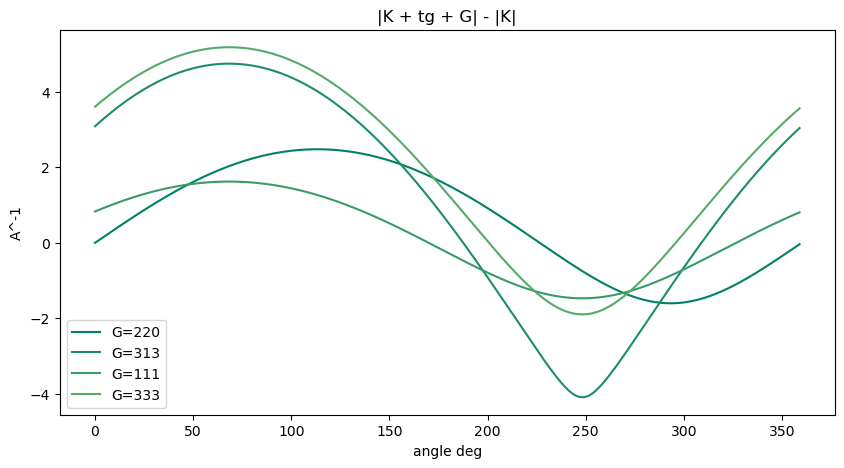

In [5]:
fig, ax = plt.subplots(ncols=1,nrows=1)
cmap = colormaps['summer']

fig.set_figheight(5)
fig.set_figwidth(10)

for gIdx in range(len(g_list)):
    ax.plot(np.arange(360), kout_len_diff[gIdx] / 1e4, label="G={}".format(labels[gIdx]), c=cmap(gIdx / 9))

plt.title('|K + tg + G| - |K|')
plt.ylabel("A^-1")
plt.xlabel('angle deg')
plt.legend()
plt.show()

In [6]:
for gIdx in range(len(g_list)):
    x = np.argmin(np.abs(kout_len_diff[gIdx] / 1e4))
    print(labels[gIdx], x)
    print(labels[gIdx], kout[gIdx, x])

    print('------------------------------')

220 0
220 [ 2584.32132665 23340.04758162 43685.21803565]
------------------------------
313 309
313 [27230.72352712 11847.241435   39746.97573925]
------------------------------
111 327
111 [-4264.47130899 12561.27996596 47906.06676206]
------------------------------
333 296
333 [24922.74468924 33066.15112494 27436.07415024]
------------------------------


In [7]:
for gIdx in range(len(g_list)):
    x = np.argmin(np.abs(kout_len_diff[gIdx] / 1e4))
    #print(labels[gIdx], x)

    k_tmp = kout[gIdx, x]
    if k_tmp[0] > 0 and k_tmp[1] > 0 and k_tmp[2] > 0:
        print(labels[gIdx], kout[gIdx, x], x + 1 - 270)

        # Normalize the wave-vector
        direction = k_tmp / np.linalg.norm(k_tmp)

        # Get the position
        position = direction / direction[2] * 12
        
        print("detector positoin with respect to the sample in cm", position)
        print('------------------------------')



220 [ 2584.32132665 23340.04758162 43685.21803565] -269
detector positoin with respect to the sample in cm [ 0.70989358  6.41133508 12.        ]
------------------------------
313 [27230.72352712 11847.241435   39746.97573925] 40
detector positoin with respect to the sample in cm [ 8.22122127  3.57679785 12.        ]
------------------------------
333 [24922.74468924 33066.15112494 27436.07415024] 27
detector positoin with respect to the sample in cm [10.90071905 14.4624851  12.        ]
------------------------------
